# Linear cellular sheaves, Gate 1: the smallest useful example

This notebook builds a cellular sheaf on a three-node path. It is deliberately smaller than the barcode problem: the goal is to understand each mathematical object before introducing overlapping barcode windows.

By the end of this gate, we will be able to explain and compute:

- vertex and edge **stalks**;
- **restriction maps** from vertices to incident edges;
- the **coboundary** $\delta$ and sheaf Laplacian $L_{\mathcal F}=\delta^\top\delta$;
- compatible assignments, or **global sections**;
- pure diffusion versus confidence-weighted recovery.

> Scope boundary: this gate stops at scalar consensus. It does not yet model barcode bars, blur, or multiple scanlines.

In [1]:
import platform
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

SEED = 7
rng = np.random.default_rng(SEED)

print(f'Python: {platform.python_version()}')
print(f'NumPy: {np.__version__}')
print(f'Matplotlib: {matplotlib.__version__}')
print(f'Executable: {sys.executable}')
print(f'Random seed: {SEED}')

Python: 3.12.3
NumPy: 1.26.4
Matplotlib: 3.6.3
Executable: /usr/bin/python3
Random seed: 7


## 1. Put local data on a graph

Our base space is the path $v_0 \rightarrow v_1 \rightarrow v_2$, with edges $e_0=(v_0,v_1)$ and $e_1=(v_1,v_2)$.

Every vertex and edge receives a one-dimensional real vector space $\mathbb R$ as its stalk. Both restriction maps incident to an edge are the identity. Therefore, two neighboring vertex values are compatible exactly when they are equal.

For an oriented edge $e=(u,v)$, the coboundary records disagreement:

$$
(\delta x)_e = \mathcal F_{v\to e}x_v - \mathcal F_{u\to e}x_u = x_v-x_u.
$$

Coboundary delta:
[[-1.  1.  0.]
 [ 0. -1.  1.]]

Sheaf Laplacian L = delta.T @ delta:
[[ 1. -1.  0.]
 [-1.  2. -1.]
 [ 0. -1.  1.]]


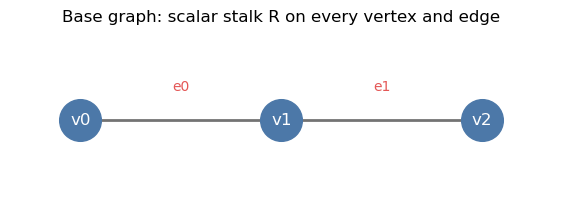

In [2]:
vertices = ('v0', 'v1', 'v2')
edges = (('v0', 'v1'), ('v1', 'v2'))

# Rows correspond to oriented edges; columns correspond to vertices.
delta = np.array([
    [-1.0,  1.0,  0.0],
    [ 0.0, -1.0,  1.0],
])
L = delta.T @ delta

print('Coboundary delta:')
print(delta)
print('\nSheaf Laplacian L = delta.T @ delta:')
print(L)

fig, ax = plt.subplots(figsize=(7, 2.2))
positions = np.array([[0.0, 0.0], [1.0, 0.0], [2.0, 0.0]])
ax.plot(positions[:, 0], positions[:, 1], color='0.45', linewidth=2, zorder=1)
ax.scatter(positions[:, 0], positions[:, 1], s=900, color='#4C78A8', zorder=2)
for (x_pos, y_pos), label in zip(positions, vertices):
    ax.text(x_pos, y_pos, label, ha='center', va='center', color='white', fontsize=12)
for edge_index, midpoint in enumerate((0.5, 1.5)):
    ax.text(midpoint, 0.13, f'e{edge_index}', ha='center', color='#E45756')
ax.set(xlim=(-0.35, 2.35), ylim=(-0.35, 0.4), title='Base graph: scalar stalk R on every vertex and edge')
ax.axis('off')
plt.show()

## 2. Compatibility, energy, and global sections

A vertex assignment $x=(x_0,x_1,x_2)$ is a global section when every overlap agrees, so $\delta x=0$. The constant assignment is compatible; a nonconstant assignment is not.

The total disagreement energy has two equivalent forms:

$$
E(x)=\lVert\delta x\rVert_2^2=x^\top L_{\mathcal F}x.
$$

Because $L_{\mathcal F}=\delta^\top\delta$, it is symmetric positive semidefinite. Its zero-eigenvalue eigenvectors are precisely the global sections in this example.

In [3]:
x_global = np.array([1.0, 1.0, 1.0])
x_inconsistent = np.array([1.0, -0.5, 0.8])

def consistency_energy(x):
    return float(np.linalg.norm(delta @ x) ** 2)

eigenvalues = np.linalg.eigvalsh(L)

print(f'delta @ global section: {delta @ x_global}')
print(f'delta @ inconsistent assignment: {delta @ x_inconsistent}')
print(f'inconsistent energy: {consistency_energy(x_inconsistent):.3f}')
print(f'Laplacian eigenvalues: {eigenvalues}')

assert delta.shape == (2, 3)
assert L.shape == (3, 3)
assert np.allclose(L, L.T)
assert np.all(eigenvalues >= -1e-12)
assert np.count_nonzero(np.isclose(eigenvalues, 0.0, atol=1e-12)) == 1
assert np.allclose(delta @ x_global, 0.0)
assert np.isclose(consistency_energy(x_inconsistent), x_inconsistent @ L @ x_inconsistent)

delta @ global section: [0. 0.]
delta @ inconsistent assignment: [-1.5  1.3]
inconsistent energy: 3.940
Laplacian eigenvalues: [3.92505363e-17 1.00000000e+00 3.00000000e+00]


## 3. Diffusion is not the same as restoration

The update $x_{t+1}=x_t-\alpha L_{\mathcal F}x_t$ decreases disagreement when the step size is stable. With this connected identity sheaf, however, pure diffusion ultimately keeps only the mean of the initial observations. It has no term requiring the result to explain trusted measurements.

For restoration, add data fidelity and confidence. Let $y$ be the measurements and $W=\operatorname{diag}(w_i)$ their confidence matrix. We solve

$$
\hat x=\arg\min_x (x-y)^\top W(x-y)+\lambda x^\top L_{\mathcal F}x,
$$

whose unique solution for positive confidence is

$$
(W+\lambda L_{\mathcal F})\hat x=Wy.
$$

In [4]:
truth = np.ones(3)
observed = np.array([1.05, -0.80, 0.90])  # The center measurement is corrupted.
confidence = np.array([1.0, 0.03, 1.0])
W = np.diag(confidence)
regularization = 1.0

weighted_solution = np.linalg.solve(W + regularization * L, W @ observed)
unweighted_solution = np.linalg.solve(np.eye(3) + regularization * L, observed)

alpha = 0.25  # Stable because alpha < 2 / largest_eigenvalue(L).
diffused = observed.copy()
diffusion_history = [diffused.copy()]
for _ in range(40):
    diffused = diffused - alpha * (L @ diffused)
    diffusion_history.append(diffused.copy())
diffusion_history = np.asarray(diffusion_history)

def weighted_data_error(x):
    residual = x - observed
    return float(residual @ W @ residual)

print(f'truth:               {truth}')
print(f'observed:            {observed}')
print(f'pure diffusion:      {diffused.round(4)}')
print(f'unweighted solution: {unweighted_solution.round(4)}')
print(f'weighted solution:   {weighted_solution.round(4)}')
print()
print(f'observed consistency energy: {consistency_energy(observed):.4f}')
print(f'weighted consistency energy: {consistency_energy(weighted_solution):.4f}')
print(f'weighted data error:          {weighted_data_error(weighted_solution):.4f}')

assert np.all(np.isfinite(weighted_solution))
assert consistency_energy(diffused) < consistency_energy(observed)
assert consistency_energy(weighted_solution) < consistency_energy(observed)
assert np.linalg.norm(weighted_solution - truth) < np.linalg.norm(observed - truth)

truth:               [1. 1. 1.]
observed:            [ 1.05 -0.8   0.9 ]
pure diffusion:      [0.3833 0.3833 0.3833]
unweighted solution: [0.5688 0.0875 0.4938]
weighted solution:   [0.9867 0.9233 0.9117]

observed consistency energy: 6.3125
weighted consistency energy: 0.0041
weighted data error:          0.0932


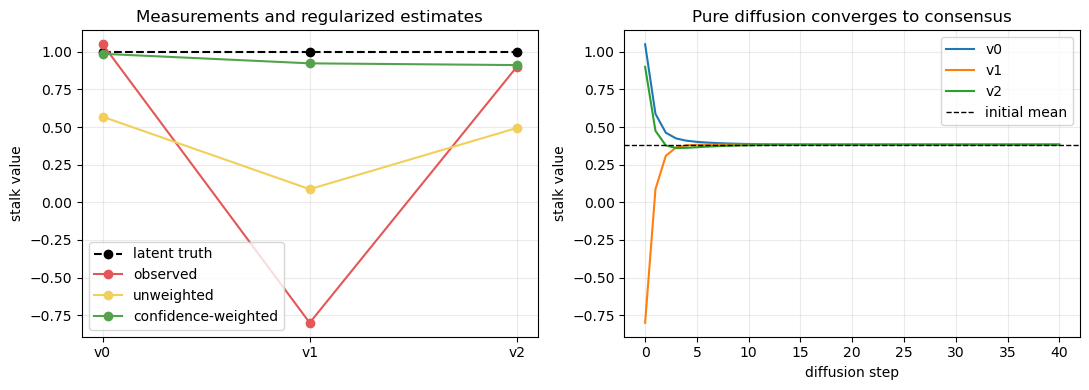

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

module_index = np.arange(3)
axes[0].plot(module_index, truth, 'k--', marker='o', label='latent truth')
axes[0].plot(module_index, observed, color='#E45756', marker='o', label='observed')
axes[0].plot(module_index, unweighted_solution, color='#F2CF5B', marker='o', label='unweighted')
axes[0].plot(module_index, weighted_solution, color='#54A24B', marker='o', label='confidence-weighted')
axes[0].set(xticks=module_index, xticklabels=vertices, ylabel='stalk value', title='Measurements and regularized estimates')
axes[0].legend()
axes[0].grid(alpha=0.25)

for vertex_index, vertex in enumerate(vertices):
    axes[1].plot(diffusion_history[:, vertex_index], label=vertex)
axes[1].axhline(observed.mean(), color='k', linestyle='--', linewidth=1, label='initial mean')
axes[1].set(xlabel='diffusion step', ylabel='stalk value', title='Pure diffusion converges to consensus')
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

## 4. What this teaches—and what it does not

We now have the complete linear cellular-sheaf pipeline in miniature:

1. the graph says which local data interact;
2. stalks say what data live at each graph cell;
3. restriction maps say what neighboring data must agree about;
4. $\delta$ measures every local disagreement;
5. $L_{\mathcal F}$ aggregates those disagreements;
6. confidence-weighted regularization balances agreement with evidence.

The restriction maps are the modeling decision. Identity maps on scalar stalks demand equality everywhere, which is useful for learning consensus but wrong for a barcode: neighboring barcode modules are allowed to differ. The next gate should use vector stalks for overlapping windows and coordinate-selection restriction maps. Those maps will require agreement only where two windows describe the same underlying module.

Gate 1 intentionally stops here. Gate 2 begins below only after review.

### Reference

Jakob Hansen and Robert Ghrist, [*Toward a Spectral Theory of Cellular Sheaves*](https://arxiv.org/abs/1808.01513).

# Gate 2: overlapping vector stalks

The scalar example required every neighboring value to be equal. That would erase a barcode's intentional black/white transitions. We now attach a **four-module vector** to each node instead. Neighboring windows advance by two modules, so they overlap on exactly two physical modules.

```text
global modules:  0 1 2 3 4 5 6 7
window 0:        [-------]
window 1:            [-------]
window 2:                [-------]
```

For an edge joining two consecutive windows, the left restriction map selects the last two coordinates of the earlier window and the right restriction map selects the first two coordinates of the later window. Only those descriptions of the **same physical modules** must agree. Values at different module positions remain free to differ.

> Scope boundary: the sequence is straight and module-aligned. This gate introduces no blur model, sensor noise, multiple scanlines, or unknown geometry.

In [6]:
binary_truth = np.array([1., 1., 0., 1., 0., 0., 1., 0.])
window_width = 4
stride = 2
overlap_width = window_width - stride
window_starts = np.arange(0, len(binary_truth) - window_width + 1, stride)
true_windows = np.stack([
    binary_truth[start:start + window_width]
    for start in window_starts
])

def coordinate_selector(indices, source_width):
    selector = np.zeros((len(indices), source_width))
    selector[np.arange(len(indices)), indices] = 1.0
    return selector

restrict_left = coordinate_selector(
    np.arange(window_width - overlap_width, window_width),
    window_width,
)
restrict_right = coordinate_selector(np.arange(overlap_width), window_width)

number_of_windows = len(true_windows)
number_of_edges = number_of_windows - 1
delta_windows = np.zeros((
    number_of_edges * overlap_width,
    number_of_windows * window_width,
))

for edge_index in range(number_of_edges):
    row = slice(edge_index * overlap_width, (edge_index + 1) * overlap_width)
    left = slice(edge_index * window_width, (edge_index + 1) * window_width)
    right = slice((edge_index + 1) * window_width, (edge_index + 2) * window_width)
    delta_windows[row, left] = -restrict_left
    delta_windows[row, right] = restrict_right

L_windows = delta_windows.T @ delta_windows
stacked_truth = true_windows.reshape(-1)
window_eigenvalues = np.linalg.eigvalsh(L_windows)
window_rank = np.linalg.matrix_rank(delta_windows)
kernel_dimension = L_windows.shape[0] - window_rank

print(f'global truth: {binary_truth.astype(int)}')
print('local window stalks:')
print(true_windows.astype(int))
print(f'coboundary shape: {delta_windows.shape}')
print(delta_windows)
print(f'delta @ stacked truth: {delta_windows @ stacked_truth}')
print(f'rank(delta): {window_rank}')
print(f'dimension of global-section space: {kernel_dimension}')

assert true_windows.shape == (3, 4)
assert delta_windows.shape == (4, 12)
assert np.allclose(delta_windows @ stacked_truth, 0.0)
assert np.allclose(L_windows, L_windows.T)
assert np.all(window_eigenvalues >= -1e-12)
assert kernel_dimension == len(binary_truth)

global truth: [1 1 0 1 0 0 1 0]
local window stalks:
[[1 1 0 1]
 [0 1 0 0]
 [0 0 1 0]]
coboundary shape: (4, 12)
[[-0. -0. -1. -0.  1.  0.  0.  0.  0.  0.  0.  0.]
 [-0. -0. -0. -1.  0.  1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -0. -0. -1. -0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0. -0. -0. -0. -1.  0.  1.  0.  0.]]
delta @ stacked truth: [0. 0. 0. 0.]
rank(delta): 4
dimension of global-section space: 8


## Why barcode transitions survive

The local state contains $3\times4=12$ values. Four independent overlap equations identify duplicate descriptions, leaving an eight-dimensional global-section space—the same dimension as the eight-module global sequence.

This is the key change from Gate 1. The kernel no longer contains only constant signals. It contains every globally defined eight-module sequence represented consistently by the three windows, including sequences with arbitrary transitions between black and white. The sheaf enforces **same module, same value**, not **neighboring module, same value**.

In [7]:
observed_windows = true_windows.copy()
observed_windows[1, 0] = 1.0  # Contradicts window 0 about global module 2.
confidence_windows = np.ones_like(observed_windows)
confidence_windows[1, 0] = 0.03  # This local value is known to be unreliable.

observed_stalks = observed_windows.reshape(-1)
confidence_stalks = confidence_windows.reshape(-1)
W_windows = np.diag(confidence_stalks)
overlap_regularization = 3.0
restored_stalks = np.linalg.solve(
    W_windows + overlap_regularization * L_windows,
    W_windows @ observed_stalks,
)
restored_windows = restored_stalks.reshape(number_of_windows, window_width)

def overlap_residuals(stalk_values):
    return (delta_windows @ np.asarray(stalk_values).reshape(-1)).reshape(
        number_of_edges, overlap_width
    )

def glue_windows(window_values):
    totals = np.zeros(len(binary_truth))
    counts = np.zeros(len(binary_truth))
    for start, values in zip(window_starts, window_values):
        totals[start:start + window_width] += values
        counts[start:start + window_width] += 1
    return totals / counts

observed_residuals = overlap_residuals(observed_stalks)
restored_residuals = overlap_residuals(restored_stalks)
glued_restoration = glue_windows(restored_windows)
restored_bits = (glued_restoration >= 0.5).astype(int)

print('observed windows:')
print(observed_windows)
print('\noverlap disagreements before restoration:')
print(observed_residuals)
print('\nrestored windows:')
print(restored_windows.round(4))
print('\noverlap disagreements after restoration:')
print(restored_residuals.round(4))
print(f'\nglued continuous sequence: {glued_restoration.round(4)}')
print(f'thresholded sequence:      {restored_bits}')

assert np.linalg.norm(restored_residuals) < np.linalg.norm(observed_residuals)
assert abs(restored_windows[1, 0] - binary_truth[2]) < abs(observed_windows[1, 0] - binary_truth[2])
assert np.array_equal(restored_bits, binary_truth.astype(int))
assert np.any(np.diff(restored_bits) != 0), 'Real barcode transitions must survive.'

observed windows:
[[1. 1. 0. 1.]
 [1. 1. 0. 0.]
 [0. 0. 1. 0.]]

overlap disagreements before restoration:
[[1. 0.]
 [0. 0.]]

restored windows:
[[1.     1.     0.0288 1.    ]
 [0.0385 1.     0.     0.    ]
 [0.     0.     1.     0.    ]]

overlap disagreements after restoration:
[[0.0096 0.    ]
 [0.     0.    ]]

glued continuous sequence: [1.     1.     0.0337 1.     0.     0.     1.     0.    ]
thresholded sequence:      [1 1 0 1 0 0 1 0]


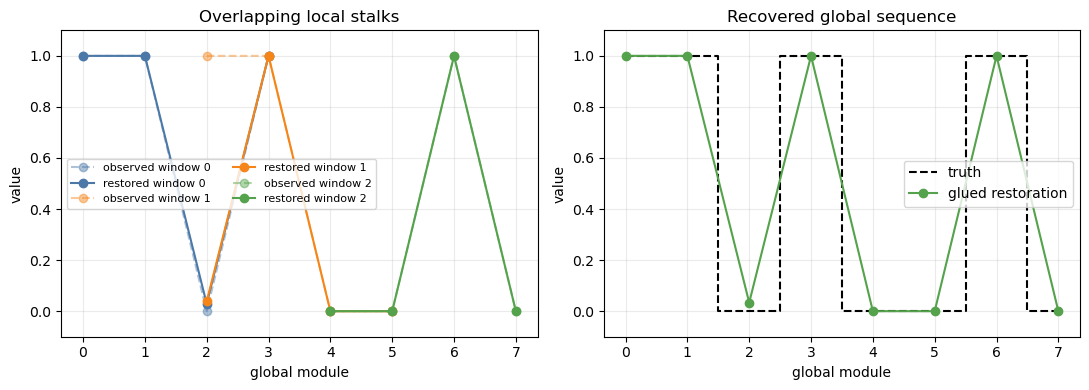

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ('#4C78A8', '#F58518', '#54A24B')
for window_index, (start, color) in enumerate(zip(window_starts, colors)):
    global_positions = np.arange(start, start + window_width)
    axes[0].plot(
        global_positions, observed_windows[window_index], 'o--',
        color=color, alpha=0.45, label=f'observed window {window_index}',
    )
    axes[0].plot(
        global_positions, restored_windows[window_index], 'o-',
        color=color, label=f'restored window {window_index}',
    )
axes[0].set(xticks=np.arange(len(binary_truth)), ylim=(-0.1, 1.1), xlabel='global module', ylabel='value', title='Overlapping local stalks')
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8, ncol=2)

axes[1].step(np.arange(len(binary_truth)), binary_truth, where='mid', color='k', linestyle='--', label='truth')
axes[1].plot(np.arange(len(binary_truth)), glued_restoration, 'o-', color='#54A24B', label='glued restoration')
axes[1].set(xticks=np.arange(len(binary_truth)), ylim=(-0.1, 1.1), xlabel='global module', ylabel='value', title='Recovered global sequence')
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
plt.show()

## Gate 2 conclusion and checkpoint

Vector stalks and coordinate-selection restriction maps solve the conceptual problem exposed by Gate 1: the sheaf can preserve arbitrary barcode transitions while detecting contradictions only where local windows describe the same physical module. Confidence-weighted regularization can pull an unreliable local copy toward a trusted overlapping copy.

This is still a consistency experiment, not a camera model. The windows are perfectly aligned and their module coordinates are known. The next gate, only after review, is fixed multi-scanline fusion with a controlled damaged region. Blur, unknown module alignment, adaptive direction, and symbology decoding remain later work.

Gate 2 intentionally stops here. Gate 3 begins below only after review.

# Gate 3: fixed multi-scanline fusion

We now copy the straight, aligned barcode across three scanlines. Every scanline is divided into the same three overlapping four-module windows used in Gate 2. The node graph is therefore a small grid:

```text
scanline 0:  w00 -- w01 -- w02
               |      |      |
scanline 1:  w10 -- w11 -- w12
               |      |      |
scanline 2:  w20 -- w21 -- w22
```

Horizontal edges use the Gate 2 coordinate selectors and compare only the two shared modules. Vertical edges connect the same window position on adjacent scanlines; because alignment is known, their restriction maps are the four-dimensional identity.

A controlled damaged region flips modules 2–4 in the middle scanline. Those measurements receive low confidence, allowing the two clear scanlines and overlap constraints to correct them. The graph does not literally route data along a chosen path: its cycles provide redundant constraints through undamaged neighboring nodes.

> Scope boundary: there is no Gaussian blur, random sensor noise, uncertain confidence estimation, or geometric misalignment in this gate.

In [9]:
number_of_scanlines = 3
windows_per_scanline = number_of_windows
node_count = number_of_scanlines * windows_per_scanline
values_per_node = window_width
variable_count = node_count * values_per_node

horizontal_edge_count = number_of_scanlines * (windows_per_scanline - 1)
vertical_edge_count = (number_of_scanlines - 1) * windows_per_scanline
horizontal_row_count = horizontal_edge_count * overlap_width
vertical_row_count = vertical_edge_count * window_width
delta_multiscan = np.zeros((horizontal_row_count + vertical_row_count, variable_count))

def node_slice(scanline_index, window_index):
    node_index = scanline_index * windows_per_scanline + window_index
    start = node_index * values_per_node
    return slice(start, start + values_per_node)

row_cursor = 0
for scanline_index in range(number_of_scanlines):
    for window_index in range(windows_per_scanline - 1):
        rows = slice(row_cursor, row_cursor + overlap_width)
        delta_multiscan[rows, node_slice(scanline_index, window_index)] = -restrict_left
        delta_multiscan[rows, node_slice(scanline_index, window_index + 1)] = restrict_right
        row_cursor += overlap_width

identity_restriction = np.eye(window_width)
for scanline_index in range(number_of_scanlines - 1):
    for window_index in range(windows_per_scanline):
        rows = slice(row_cursor, row_cursor + window_width)
        delta_multiscan[rows, node_slice(scanline_index, window_index)] = -identity_restriction
        delta_multiscan[rows, node_slice(scanline_index + 1, window_index)] = identity_restriction
        row_cursor += window_width

L_multiscan = delta_multiscan.T @ delta_multiscan
clean_scanlines = np.tile(binary_truth, (number_of_scanlines, 1))
true_window_grid = np.stack([
    np.stack([row[start:start + window_width] for start in window_starts])
    for row in clean_scanlines
])
stacked_multiscan_truth = true_window_grid.reshape(-1)
multiscan_rank = np.linalg.matrix_rank(delta_multiscan)
multiscan_kernel_dimension = variable_count - multiscan_rank
multiscan_eigenvalues = np.linalg.eigvalsh(L_multiscan)

print(f'nodes: {node_count} = {number_of_scanlines} scanlines x {windows_per_scanline} windows')
print(f'variables: {variable_count} = {node_count} nodes x {values_per_node} values')
print(f'horizontal edges: {horizontal_edge_count}, contributing {horizontal_row_count} comparisons')
print(f'vertical edges: {vertical_edge_count}, contributing {vertical_row_count} comparisons')
print(f'coboundary shape: {delta_multiscan.shape}')
print(f'rank(delta): {multiscan_rank}')
print(f'dimension of global-section space: {multiscan_kernel_dimension}')
print(f'maximum truth disagreement: {np.abs(delta_multiscan @ stacked_multiscan_truth).max():.1f}')

assert row_cursor == delta_multiscan.shape[0]
assert delta_multiscan.shape == (36, 36)
assert np.allclose(delta_multiscan @ stacked_multiscan_truth, 0.0)
assert np.allclose(L_multiscan, L_multiscan.T)
assert np.all(multiscan_eigenvalues >= -1e-12)
assert multiscan_kernel_dimension == len(binary_truth)

nodes: 9 = 3 scanlines x 3 windows
variables: 36 = 9 nodes x 4 values
horizontal edges: 6, contributing 12 comparisons
vertical edges: 6, contributing 24 comparisons
coboundary shape: (36, 36)
rank(delta): 28
dimension of global-section space: 8
maximum truth disagreement: 0.0


## What the larger coboundary represents

There are $9\times4=36$ locally stored values. The coboundary also has 36 rows: 12 horizontal overlap comparisons and 24 vertical cross-scanline comparisons. Some equations are redundant because the grid contains cycles, so the matrix rank is 28 rather than 36. Its kernel still has dimension $36-28=8$: a compatible assignment is determined by one arbitrary eight-module global sequence copied consistently into every overlapping window and scanline.

This is the algebraic version of redundant evidence. A value in the damaged middle row is constrained horizontally by its window overlaps and vertically by corresponding clear windows above and below.

In [10]:
observed_scanlines = clean_scanlines.copy()
damaged_scanline_index = 1
damaged_modules = np.arange(2, 5)
observed_scanlines[damaged_scanline_index, damaged_modules] = (
    1.0 - observed_scanlines[damaged_scanline_index, damaged_modules]
)

scanline_confidence = np.ones_like(observed_scanlines)
scanline_confidence[damaged_scanline_index, damaged_modules] = 0.02

def windowize_scanlines(scanline_values):
    return np.stack([
        np.stack([row[start:start + window_width] for start in window_starts])
        for row in scanline_values
    ])

observed_window_grid = windowize_scanlines(observed_scanlines)
confidence_window_grid = windowize_scanlines(scanline_confidence)
observed_multiscan_stalks = observed_window_grid.reshape(-1)
confidence_multiscan_stalks = confidence_window_grid.reshape(-1)
W_multiscan = np.diag(confidence_multiscan_stalks)
multiscan_regularization = 2.0
restored_multiscan_stalks = np.linalg.solve(
    W_multiscan + multiscan_regularization * L_multiscan,
    W_multiscan @ observed_multiscan_stalks,
)
restored_window_grid = restored_multiscan_stalks.reshape(
    number_of_scanlines, windows_per_scanline, window_width
)
restored_scanlines = np.stack([
    glue_windows(restored_window_grid[scanline_index])
    for scanline_index in range(number_of_scanlines)
])
fused_restoration = restored_scanlines.mean(axis=0)
restored_multiscan_bits = (fused_restoration >= 0.5).astype(int)

plain_mean = observed_scanlines.mean(axis=0)
confidence_mean = (scanline_confidence * observed_scanlines).sum(axis=0) / scanline_confidence.sum(axis=0)
observed_energy = float(np.linalg.norm(delta_multiscan @ observed_multiscan_stalks) ** 2)
restored_energy = float(np.linalg.norm(delta_multiscan @ restored_multiscan_stalks) ** 2)

print('observed scanlines:')
print(observed_scanlines.astype(int))
print('\nconfidence map:')
print(scanline_confidence)
print('\nrestored scanlines:')
print(restored_scanlines.round(4))
print(f'\nplain per-module mean:      {plain_mean.round(4)}')
print(f'confidence-weighted mean:  {confidence_mean.round(4)}')
print(f'sheaf fused restoration:  {fused_restoration.round(4)}')
print(f'sheaf thresholded result: {restored_multiscan_bits}')
print(f'\nconsistency energy: {observed_energy:.4f} -> {restored_energy:.6f}')

assert not np.array_equal(observed_scanlines[damaged_scanline_index].astype(int), binary_truth.astype(int))
assert restored_energy < observed_energy
assert np.array_equal(restored_multiscan_bits, binary_truth.astype(int))
assert np.linalg.norm(fused_restoration - binary_truth) < np.linalg.norm(plain_mean - binary_truth)

observed scanlines:
[[1 1 0 1 0 0 1 0]
 [1 1 1 0 1 0 1 0]
 [1 1 0 1 0 0 1 0]]

confidence map:
[[1.   1.   1.   1.   1.   1.   1.   1.  ]
 [1.   1.   0.02 0.02 0.02 1.   1.   1.  ]
 [1.   1.   1.   1.   1.   1.   1.   1.  ]]

restored scanlines:
[[1.     1.     0.0099 0.9901 0.0099 0.     1.     0.    ]
 [1.     1.     0.0148 0.9852 0.0148 0.     1.     0.    ]
 [1.     1.     0.0099 0.9901 0.0099 0.     1.     0.    ]]

plain per-module mean:      [1.     1.     0.3333 0.6667 0.3333 0.     1.     0.    ]
confidence-weighted mean:  [1.     1.     0.0099 0.9901 0.0099 0.     1.     0.    ]
sheaf fused restoration:  [1.     1.     0.0115 0.9885 0.0115 0.     1.     0.    ]
sheaf thresholded result: [1 1 0 1 0 0 1 0]

consistency energy: 12.0000 -> 0.000291


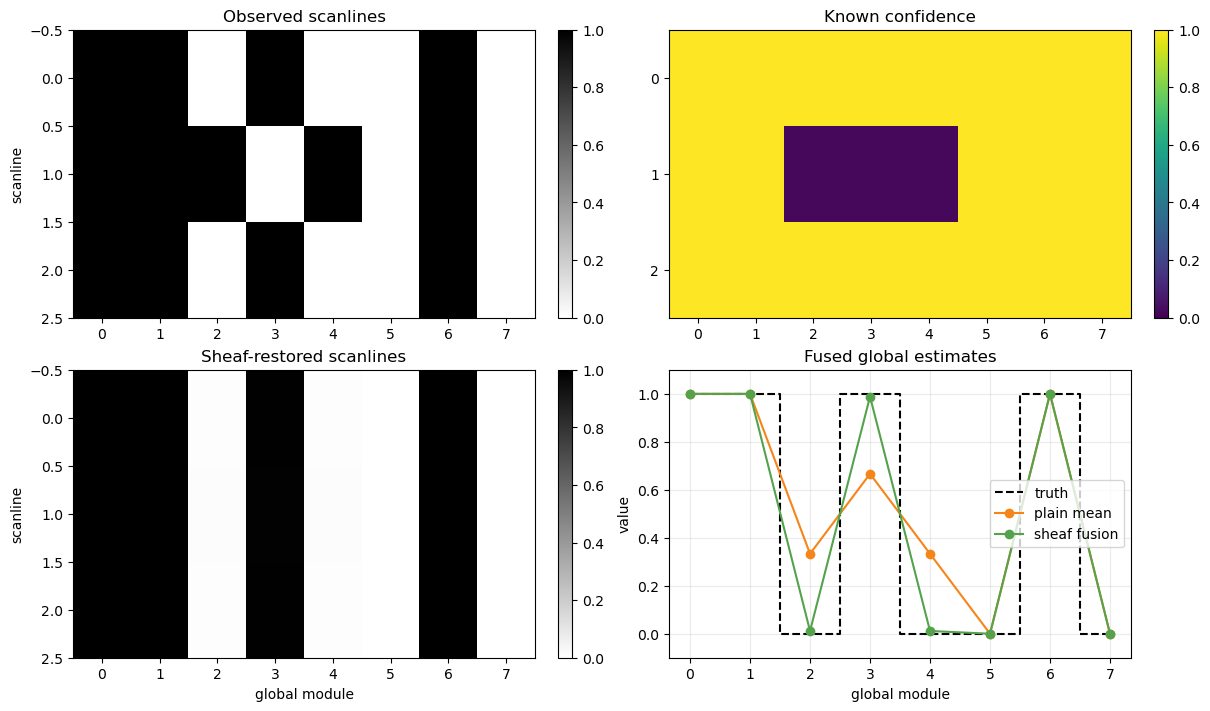

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

image_options = dict(aspect='auto', interpolation='nearest', vmin=0, vmax=1, cmap='gray_r')
observed_image = axes[0, 0].imshow(observed_scanlines, **image_options)
axes[0, 0].set(title='Observed scanlines', ylabel='scanline', xticks=np.arange(len(binary_truth)))
fig.colorbar(observed_image, ax=axes[0, 0], fraction=0.046)

confidence_image = axes[0, 1].imshow(scanline_confidence, aspect='auto', interpolation='nearest', vmin=0, vmax=1, cmap='viridis')
axes[0, 1].set(title='Known confidence', xticks=np.arange(len(binary_truth)), yticks=np.arange(number_of_scanlines))
fig.colorbar(confidence_image, ax=axes[0, 1], fraction=0.046)

restored_image = axes[1, 0].imshow(restored_scanlines, **image_options)
axes[1, 0].set(title='Sheaf-restored scanlines', xlabel='global module', ylabel='scanline', xticks=np.arange(len(binary_truth)))
fig.colorbar(restored_image, ax=axes[1, 0], fraction=0.046)

module_positions = np.arange(len(binary_truth))
axes[1, 1].step(module_positions, binary_truth, where='mid', color='k', linestyle='--', label='truth')
axes[1, 1].plot(module_positions, plain_mean, 'o-', color='#F58518', label='plain mean')
axes[1, 1].plot(module_positions, fused_restoration, 'o-', color='#54A24B', label='sheaf fusion')
axes[1, 1].set(title='Fused global estimates', xlabel='global module', ylabel='value', xticks=module_positions, ylim=(-0.1, 1.1))
axes[1, 1].grid(alpha=0.25)
axes[1, 1].legend()

plt.show()

## Gate 3 conclusion and checkpoint

The grid sheaf fuses redundant scanlines while retaining the overlap semantics from Gate 2. Low-confidence measurements in one local region are pulled toward compatible evidence above, below, left, and right. This is the first small demonstration of the proposed damage-recovery mechanism.

The comparison also matters: because every scanline is perfectly aligned and confidence is already known, a simple per-module confidence-weighted mean is a strong baseline and nearly solves this toy problem directly. The sheaf formulation must later justify itself when overlaps, local geometry, missing coverage, or decoder constraints make simple averaging insufficient.

Gate 3 intentionally stops here. Gate 4 begins below only after review.

# Gate 4: Gaussian blur and sensor noise

The previous gates treated each stalk value as a direct observation of one latent module. A camera instead measures a transformed signal: neighboring black and white modules blend through the optics, and the sensor adds noise. For each four-module node we now use

$$y_i = Hx_i + \varepsilon_i,$$

where $x_i$ is the latent local module vector, $H$ is a row-normalized Gaussian blur matrix, and $\varepsilon_i$ is seeded zero-mean Gaussian noise. The joint estimator becomes

$$
\hat x=\arg\min_x
\lVert W^{1/2}(Hx-y)\rVert^2
+\lambda\lVert\delta x\rVert^2
+\eta\lVert x\rVert^2.
$$

The first term explains the blurred measurements, the second enforces sheaf consistency among latent windows, and the small final Tikhonov term stabilizes deconvolution. The same stabilizer is used in the independent-deconvolution baseline.

> This remains a deliberately simplified **module-space** blur model. It does not yet render bars into pixels, estimate module pitch, or infer the optical point-spread function.

In [12]:
gate4_seed = SEED + 4
gate4_rng = np.random.default_rng(gate4_seed)
blur_sigma_modules = 1.0
sensor_noise_std = 0.10

local_coordinates = np.arange(window_width)
coordinate_distance = local_coordinates[:, None] - local_coordinates[None, :]
blur_matrix = np.exp(-(coordinate_distance ** 2) / (2 * blur_sigma_modules ** 2))
blur_matrix /= blur_matrix.sum(axis=1, keepdims=True)
H_multiscan = np.kron(np.eye(node_count), blur_matrix)

blurred_noiseless_stalks = H_multiscan @ stacked_multiscan_truth
gate4_observations = blurred_noiseless_stalks + gate4_rng.normal(
    0.0, sensor_noise_std, size=variable_count
)

# Retain the controlled low-confidence damaged region from Gate 3. It is
# saturated near gray rather than flipped after the optical blur is applied.
gate4_confidence = confidence_multiscan_stalks.copy()
gate4_damage_mask = gate4_confidence < 0.1
gate4_observations[gate4_damage_mask] = 0.5 + gate4_rng.normal(
    0.0, sensor_noise_std, size=np.count_nonzero(gate4_damage_mask)
)
gate4_observations = np.clip(gate4_observations, 0.0, 1.0)
gate4_observation_grid = gate4_observations.reshape(
    number_of_scanlines, windows_per_scanline, window_width
)
gate4_observed_scanlines = np.stack([
    glue_windows(gate4_observation_grid[scanline_index])
    for scanline_index in range(number_of_scanlines)
])

print(f'random seed: {gate4_seed}')
print(f'blur sigma: {blur_sigma_modules:.2f} modules')
print(f'sensor noise standard deviation: {sensor_noise_std:.2f}')
print('\nlocal Gaussian blur matrix H:')
print(blur_matrix.round(4))
print('\nglued blurred/noisy observations:')
print(gate4_observed_scanlines.round(4))

assert np.allclose(blur_matrix.sum(axis=1), 1.0)
assert H_multiscan.shape == (variable_count, variable_count)
assert np.all((gate4_observations >= 0.0) & (gate4_observations <= 1.0))
assert np.count_nonzero(gate4_damage_mask) > 0

random seed: 11
blur sigma: 1.00 modules
sensor noise standard deviation: 0.10

local Gaussian blur matrix H:
[[0.5705 0.346  0.0772 0.0063]
 [0.2583 0.4258 0.2583 0.0576]
 [0.0576 0.2583 0.4258 0.2583]
 [0.0063 0.0772 0.346  0.5705]]

glued blurred/noisy observations:
[[0.9262 0.8777 0.5064 0.488  0.2336 0.0726 0.5825 0.3364]
 [0.9908 0.7281 0.5169 0.5115 0.5298 0.1263 0.4653 0.2789]
 [0.7308 0.6603 0.3621 0.4821 0.1754 0.1753 0.4975 0.316 ]]


## Compare increasingly structured estimators

Four estimators use the same generated data:

1. **Raw mean:** glue local observations and average the three scanlines, without using confidence or $H$.
2. **Confidence mean:** downweight the known damaged region, but still ignore blur.
3. **Independent deconvolution:** use $H$, confidence, and the stabilizer, but do not connect any stalks with $\delta$.
4. **Joint sheaf deconvolution:** use the same observation model plus the multi-scanline consistency penalty.

This ablation distinguishes gains from confidence, gains from modeling blur, and gains from local-to-global consistency.

In [13]:
gate4_W = np.diag(gate4_confidence)
tikhonov_strength = 0.02
gate4_sheaf_strength = 2.0
identity_variables = np.eye(variable_count)
normal_data_matrix = H_multiscan.T @ gate4_W @ H_multiscan
normal_data_vector = H_multiscan.T @ gate4_W @ gate4_observations

independent_latent_stalks = np.linalg.solve(
    normal_data_matrix + tikhonov_strength * identity_variables,
    normal_data_vector,
)
sheaf_latent_stalks = np.linalg.solve(
    normal_data_matrix
    + gate4_sheaf_strength * L_multiscan
    + tikhonov_strength * identity_variables,
    normal_data_vector,
)

def glue_multiscan_stalks(stalk_values):
    window_grid = np.asarray(stalk_values).reshape(
        number_of_scanlines, windows_per_scanline, window_width
    )
    return np.stack([glue_windows(window_grid[row]) for row in range(number_of_scanlines)])

raw_mean_estimate = gate4_observed_scanlines.mean(axis=0)
confidence_mean_estimate = (
    scanline_confidence * gate4_observed_scanlines
).sum(axis=0) / scanline_confidence.sum(axis=0)
independent_scanline_estimates = glue_multiscan_stalks(independent_latent_stalks)
independent_estimate = independent_scanline_estimates.mean(axis=0)
sheaf_scanline_estimates = glue_multiscan_stalks(sheaf_latent_stalks)
sheaf_estimate = sheaf_scanline_estimates.mean(axis=0)

estimators = {
    'raw mean': raw_mean_estimate,
    'confidence mean': confidence_mean_estimate,
    'independent deconvolution': independent_estimate,
    'joint sheaf deconvolution': sheaf_estimate,
}

def restoration_metrics(estimate):
    estimate = np.asarray(estimate)
    decoded = (estimate >= 0.5).astype(int)
    rmse = float(np.sqrt(np.mean((estimate - binary_truth) ** 2)))
    bit_error_rate = float(np.mean(decoded != binary_truth.astype(int)))
    return rmse, bit_error_rate, decoded

print(f"{'estimator':28s} {'RMSE':>8s} {'BER':>8s}  thresholded modules")
print('-' * 70)
gate4_metrics = {}
for name, estimate in estimators.items():
    rmse, bit_error_rate, decoded = restoration_metrics(estimate)
    gate4_metrics[name] = (rmse, bit_error_rate, decoded)
    print(f'{name:28s} {rmse:8.4f} {bit_error_rate:8.4f}  {decoded}')

independent_consistency = float(np.linalg.norm(delta_multiscan @ independent_latent_stalks) ** 2)
sheaf_consistency = float(np.linalg.norm(delta_multiscan @ sheaf_latent_stalks) ** 2)
print(f'\nlatent consistency energy: independent={independent_consistency:.6f}, sheaf={sheaf_consistency:.6f}')
print(f'sheaf continuous estimate: {sheaf_estimate.round(4)}')

assert gate4_metrics['raw mean'][1] > 0.0
assert gate4_metrics['independent deconvolution'][1] > 0.0
assert gate4_metrics['joint sheaf deconvolution'][1] == 0.0
assert gate4_metrics['joint sheaf deconvolution'][0] < gate4_metrics['independent deconvolution'][0]
assert sheaf_consistency < independent_consistency

estimator                        RMSE      BER  thresholded modules
----------------------------------------------------------------------
raw mean                       0.3514   0.1250  [1 1 0 0 0 0 1 0]
confidence mean                0.3387   0.1250  [1 1 0 0 0 0 1 0]
independent deconvolution      0.2419   0.1250  [1 1 0 0 0 0 1 0]
joint sheaf deconvolution      0.1534   0.0000  [1 1 0 1 0 0 1 0]

latent consistency energy: independent=3.518205, sheaf=0.008264
sheaf continuous estimate: [0.8445 1.0508 0.141  0.7143 0.0763 0.0227 0.8078 0.1297]


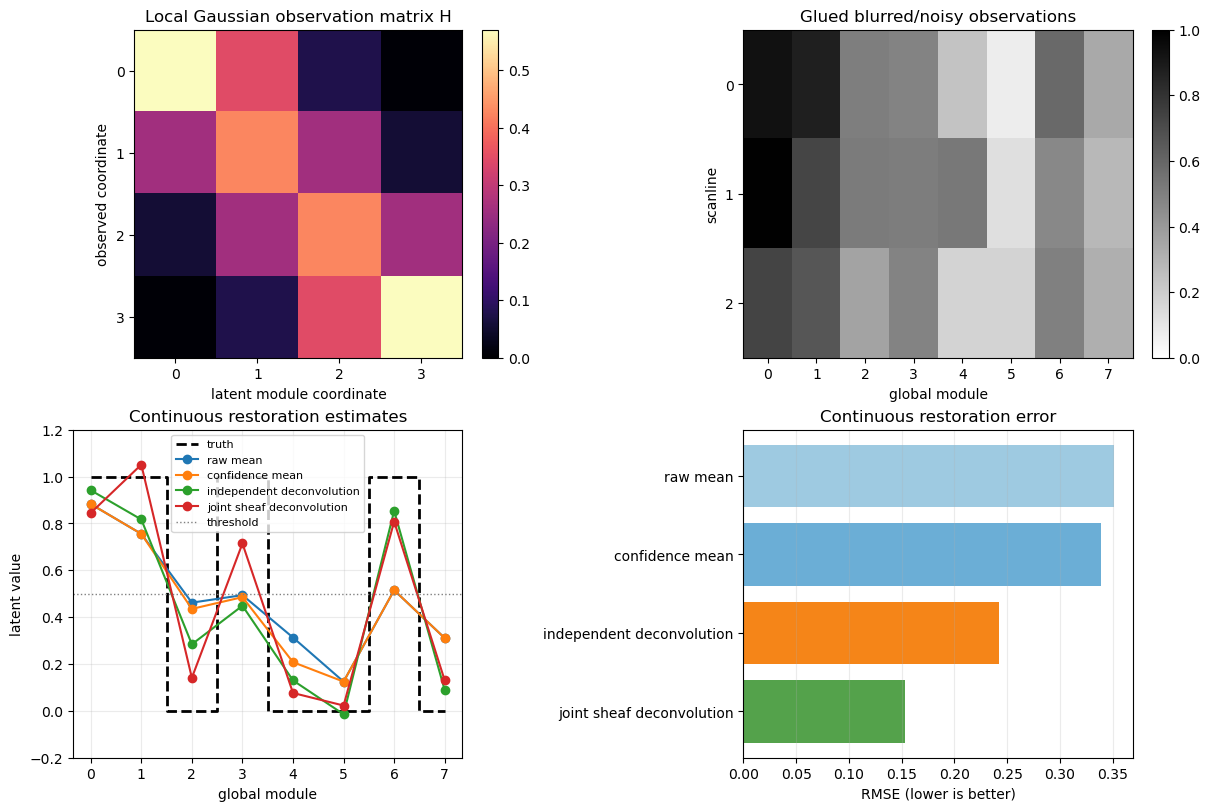

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

blur_image = axes[0, 0].imshow(blur_matrix, vmin=0, vmax=blur_matrix.max(), cmap='magma')
axes[0, 0].set(title='Local Gaussian observation matrix H', xlabel='latent module coordinate', ylabel='observed coordinate', xticks=np.arange(window_width), yticks=np.arange(window_width))
fig.colorbar(blur_image, ax=axes[0, 0], fraction=0.046)

observation_image = axes[0, 1].imshow(gate4_observed_scanlines, aspect='auto', interpolation='nearest', vmin=0, vmax=1, cmap='gray_r')
axes[0, 1].set(title='Glued blurred/noisy observations', xlabel='global module', ylabel='scanline', xticks=np.arange(len(binary_truth)), yticks=np.arange(number_of_scanlines))
fig.colorbar(observation_image, ax=axes[0, 1], fraction=0.046)

module_positions = np.arange(len(binary_truth))
axes[1, 0].step(module_positions, binary_truth, where='mid', color='k', linewidth=2, linestyle='--', label='truth')
for name, estimate in estimators.items():
    axes[1, 0].plot(module_positions, estimate, 'o-', label=name)
axes[1, 0].axhline(0.5, color='0.5', linewidth=1, linestyle=':', label='threshold')
axes[1, 0].set(title='Continuous restoration estimates', xlabel='global module', ylabel='latent value', xticks=module_positions, ylim=(-0.2, 1.2))
axes[1, 0].grid(alpha=0.25)
axes[1, 0].legend(fontsize=8)

metric_names = list(estimators)
rmse_values = [gate4_metrics[name][0] for name in metric_names]
axes[1, 1].barh(metric_names, rmse_values, color=('#9ECAE1', '#6BAED6', '#F58518', '#54A24B'))
axes[1, 1].invert_yaxis()
axes[1, 1].set(title='Continuous restoration error', xlabel='RMSE (lower is better)')
axes[1, 1].grid(axis='x', alpha=0.25)

plt.show()

## Gate 4 conclusion and checkpoint

For this fixed seeded example, confidence alone is insufficient because it cannot undo optical mixing. Independent local deconvolution models the blur but amplifies ambiguity and does not reconcile duplicate latent modules. Adding sheaf consistency produces the lowest continuous error and the only exact thresholded sequence among the tested deconvolution variants.

This is evidence for the joint formulation, not yet a performance claim. It is one short hand-selected sequence, one blur level, one noise realization, oracle alignment, oracle confidence, and a known blur matrix. The unconstrained linear relaxation can also return values slightly outside $[0,1]$; a later estimator may need box constraints or calibrated probabilities.

This notebook intentionally stops here. The next gate, only after review, should run a small seeded sweep over blur, noise, and damage levels to measure where each method succeeds or fails, together with runtime and working-memory estimates. Unknown alignment, adaptive direction, real symbology, and checksum validation remain later work.